# EfficientNet-B0 FER2013 Experiments

Focused transfer-learning notebook for EfficientNet-B0. This keeps EfficientNet experiments separate from ResNet18 so results and configs are easier to report.

In [1]:
from pathlib import Path
import json
import random
import sys

import importlib
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fer2013_images'
# Kaggle option:
# DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')

RESULTS_DIR = PROJECT_ROOT / 'results'
(RESULTS_DIR / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE, DATA_DIR

(device(type='cuda'), PosixPath('/kaggle/working/data/raw/fer2013_images'))

## Kaggle Path Setup Option

Use this block only when running the notebook in Kaggle. It clones or updates the repository, then points `DATA_DIR` to the Kaggle FER2013 dataset folder.

In [2]:
# Kaggle option. Uncomment this block only when running in Kaggle.

%cd /kaggle/working
from pathlib import Path
import sys

REPO_URL = 'https://github.com/zsykk/DL-final-project.git'
REPO_DIR = 'DL-final-project'

if Path(REPO_DIR).exists():
    %cd /kaggle/working/DL-final-project
    !git pull
else:
    !git clone {REPO_URL}
    %cd /kaggle/working/DL-final-project

PROJECT_ROOT = Path('/kaggle/working/DL-final-project')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')
RESULTS_DIR = PROJECT_ROOT / 'results'
(RESULTS_DIR / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)

DATA_DIR, (DATA_DIR / 'train').exists(), (DATA_DIR / 'test').exists(), PROJECT_ROOT

/kaggle/working
Cloning into 'DL-final-project'...
remote: Enumerating objects: 532, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 532 (delta 5), reused 21 (delta 5), pack-reused 507 (from 2)
Receiving objects: 100% (532/532), 957.61 MiB | 42.44 MiB/s, done.
Resolving deltas: 100% (211/211), done.
Updating files: 100% (227/227), done.
/kaggle/working/DL-final-project


(PosixPath('/kaggle/input/datasets/msambare/fer2013'),
 True,
 True,
 PosixPath('/kaggle/working/DL-final-project'))

In [3]:
from fer_project.data import TransformConfig, build_imagefolder_dataloaders, class_weights, dataset_labels
from fer_project.models import build_model

import fer_project.training as training
training = importlib.reload(training)
fit = training.fit
fit_sgd_schedule = training.fit_sgd_schedule

import fer_project.metrics as metrics
metrics = importlib.reload(metrics)
collect_predictions = metrics.collect_predictions
plot_training_and_confusion = metrics.plot_training_and_confusion
save_classification_report = metrics.save_classification_report
top_confusions = metrics.top_confusions


In [4]:
TRANSFER_TRAIN_CONFIG = TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True)
TRANSFER_EVAL_CONFIG = TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True)
EFFICIENTNET_B0_SMALL_CLASSIFIER = [256]
EFFICIENTNET_B0_CLASSIFIER_DROPOUT = 0.4

EMOTION_ROWS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']


def save_experiment_config(name, config):
    path = RESULTS_DIR / 'metrics' / f'{name}_config.json'
    with open(path, 'w') as f:
        json.dump(config, f, indent=2, default=str)
    return path


def build_transfer_loaders(batch_size=64, num_workers=0, subset_fraction=1.0, weighted_sampler=False):
    return build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=TRANSFER_TRAIN_CONFIG,
        eval_config=TRANSFER_EVAL_CONFIG,
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=weighted_sampler,
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=SEED,
    )


def set_efficientnet_b0_trainable_layers(model, unfreeze_from='classifier'):
    for parameter in model.parameters():
        parameter.requires_grad = False

    if unfreeze_from == 'classifier':
        modules = [model.classifier]
    elif unfreeze_from == 'last_block':
        modules = [model.features[-1], model.classifier]
    elif unfreeze_from == 'last_blocks':
        modules = [model.features[-2], model.features[-1], model.classifier]
    elif unfreeze_from == 'last_three_blocks':
        modules = [model.features[-3], model.features[-2], model.features[-1], model.classifier]
    elif unfreeze_from == 'all':
        modules = [model]
    else:
        raise ValueError("unfreeze_from must be one of: 'classifier', 'last_block', 'last_blocks', 'last_three_blocks', 'all'")

    for module in modules:
        for parameter in module.parameters():
            parameter.requires_grad = True
    return model


def best_history_row(history_frame):
    return history_frame.sort_values(['val_macro_f1', 'val_loss'], ascending=[False, True]).iloc[0]


def finalize_model_run(model, loaders, history, name, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions(model, loaders['test'], DEVICE)
    report = save_classification_report(y_true, y_pred, RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv')
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    plot_training_and_confusion(
        history_frame,
        y_true,
        y_pred,
        f'{name}: loss and confusion matrix',
        RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png',
    )

    best_row = best_history_row(history_frame)
    print(f'Best checkpoint saved to: {checkpoint_path}')
    print('Best validation row:')
    display(best_row[['epoch', 'stage', 'stage_epoch', 'lr', 'train_macro_f1', 'val_macro_f1', 'val_loss']])
    print('Recent training history:')
    display(history_frame.tail())
    print('Test summary:')
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[EMOTION_ROWS, ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history_frame, report, confusions


## Independent Unfreeze Depth Search

Each cell below starts from a fresh ImageNet-pretrained EfficientNet-B0, replaces the classifier with the same dropout-regularized `1280 -> 256 -> 7` head, freezes the requested prefix of the feature extractor, and saves its own best checkpoint. This mirrors the ResNet18 notebook while using EfficientNet's own block structure.


In [5]:
EFFICIENTNET_B0_DEPTH_LRS = {
    'classifier': 1e-3,
    'last_block': 5e-4,
    'last_blocks': 1e-4,
    'last_three_blocks': 5e-5,
    'all': 1e-5,
}

DEPTH_SEARCH_NAMES = [
    'efficientnet_b0_feature_extract_classifier',
    'efficientnet_b0_unfreeze_last_block',
    'efficientnet_b0_unfreeze_last_blocks',
    'efficientnet_b0_unfreeze_last_three_blocks',
]


def build_fresh_efficientnet_b0(
    unfreeze_from='classifier',
    classifier_hidden_layers=EFFICIENTNET_B0_SMALL_CLASSIFIER,
    classifier_dropout=EFFICIENTNET_B0_CLASSIFIER_DROPOUT,
):
    set_seed(SEED)
    model = build_model(
        'transfer',
        transfer_model='efficientnet_b0',
        pretrained=True,
        freeze_backbone=False,
        classifier_hidden_layers=classifier_hidden_layers,
        classifier_dropout=classifier_dropout,
    )
    set_efficientnet_b0_trainable_layers(model, unfreeze_from)
    return model


def run_efficientnet_b0_fresh_experiment(
    name,
    unfreeze_from='classifier',
    batch_size=64,
    num_workers=0,
    subset_fraction=1.0,
    epochs=15,
    lr=None,
    optimizer_name='adamw',
    weight_decay=1e-4,
    use_class_weights=False,
    weighted_sampler=False,
    loss_name='cross_entropy',
    focal_gamma=1.0,
    classifier_hidden_layers=EFFICIENTNET_B0_SMALL_CLASSIFIER,
    classifier_dropout=EFFICIENTNET_B0_CLASSIFIER_DROPOUT,
    lr_decay_rate=0.1,
    lr_plateau_patience=5,
    lr_plateau_threshold=1e-3,
    min_lr=1e-6,
):
    lr = EFFICIENTNET_B0_DEPTH_LRS[unfreeze_from] if lr is None else lr
    loaders, datasets = build_transfer_loaders(
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
        weighted_sampler=weighted_sampler,
    )
    model = build_fresh_efficientnet_b0(
        unfreeze_from=unfreeze_from,
        classifier_hidden_layers=classifier_hidden_layers,
        classifier_dropout=classifier_dropout,
    )
    weights = class_weights(dataset_labels(datasets['train'])) if use_class_weights else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'

    if optimizer_name == 'sgd_plateau':
        history, _ = fit_sgd_schedule(
            model,
            loaders,
            device=DEVICE,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            class_weight=weights,
            loss_name=loss_name,
            focal_gamma=focal_gamma,
            lr_decay_rate=lr_decay_rate,
            lr_plateau_patience=lr_plateau_patience,
            lr_plateau_threshold=lr_plateau_threshold,
            min_lr=min_lr,
            checkpoint_path=checkpoint_path,
            stage_name=f'unfreeze_{unfreeze_from}',
        )
    elif optimizer_name == 'adamw':
        history = fit(
            model,
            loaders,
            device=DEVICE,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            class_weight=weights,
            loss_name=loss_name,
            focal_gamma=focal_gamma,
            checkpoint_path=checkpoint_path,
        )
        history = [
            {
                'stage': f'unfreeze_{unfreeze_from}',
                'stage_epoch': row['epoch'],
                'lr': lr,
                **row,
            }
            for row in history
        ]
    else:
        raise ValueError("optimizer_name must be 'adamw' or 'sgd_plateau'")

    save_experiment_config(name, {
        'name': name,
        'model': 'efficientnet_b0',
        'source_weights': 'ImageNet pretrained EfficientNet-B0; no previous FER2013 checkpoint loaded',
        'classifier_hidden_layers': classifier_hidden_layers,
        'classifier_dropout': classifier_dropout,
        'classifier_shape': '1280 -> 256 -> 7',
        'unfreeze_from': unfreeze_from,
        'optimizer_name': optimizer_name,
        'epochs': epochs,
        'lr': lr,
        'weight_decay': weight_decay,
        'use_class_weights': use_class_weights,
        'weighted_sampler': weighted_sampler,
        'loss_name': loss_name,
        'focal_gamma': focal_gamma,
        'selection_rule': 'highest validation macro F1; lower validation loss tie-breaker',
        'train_transform': '224x224 grayscale replicated to 3 channels, augment=True, ImageNet normalization',
        'eval_transform': '224x224 grayscale replicated to 3 channels, augment=False, ImageNet normalization',
        'checkpoint': checkpoint_path,
    })
    return finalize_model_run(model, loaders, history, name, checkpoint_path)


### Feature Extraction: Classifier Only

Train only the new dropout classifier head. This is the clean EfficientNet-B0 feature-extraction baseline.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 1.4607, 'train_macro_f1': 0.3545, 'train_weighted_f1': 0.4145, 'val_loss': 1.4138, 'val_macro_f1': 0.3578, 'val_weighted_f1': 0.4199}


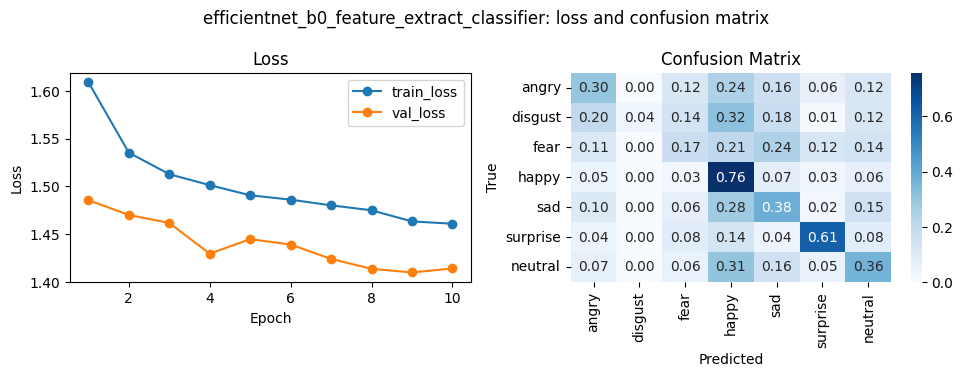

Best checkpoint saved to: /kaggle/working/DL-final-project/results/checkpoints/efficientnet_b0_feature_extract_classifier.pt
Best validation row:


epoch                               9
stage             unfreeze_classifier
stage_epoch                         9
lr                              0.001
train_macro_f1               0.353988
val_macro_f1                 0.381574
val_loss                     1.409594
Name: 8, dtype: object

Recent training history:


,stage,stage_epoch,lr,epoch,train_loss,train_macro_f1,train_weighted_f1,val_loss,val_macro_f1,val_weighted_f1
5,unfreeze_classifier,6,0.001,6,1.485911,0.346423,0.409689,1.438867,0.359996,0.426753
6,unfreeze_classifier,7,0.001,7,1.479973,0.350423,0.413165,1.423756,0.357813,0.421039
7,unfreeze_classifier,8,0.001,8,1.474757,0.352142,0.416401,1.413408,0.364850,0.428725
8,unfreeze_classifier,9,0.001,9,1.463131,0.353988,0.415778,1.409594,0.381574,0.439003
9,unfreeze_classifier,10,0.001,10,1.460674,0.354510,0.414453,1.413797,0.357765,0.419929


Test summary:


,precision,recall,f1-score,support
macro avg,0.427017,0.374173,0.371523,7178.0
weighted avg,0.432009,0.451379,0.429339,7178.0


,precision,recall,f1-score,support
angry,0.381649,0.299582,0.335673,958.0
disgust,0.400000,0.036036,0.066116,111.0
fear,0.309187,0.170898,0.220126,1024.0
happy,0.505445,0.758737,0.606716,1774.0
sad,0.375299,0.377706,0.376499,1247.0
surprise,0.609319,0.613718,0.611511,831.0
neutral,0.408219,0.362530,0.384021,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
36,neutral,happy,377,0.305758
25,sad,happy,346,0.277466
15,fear,sad,249,0.243164
2,angry,happy,234,0.244259
14,fear,happy,211,0.206055
27,sad,neutral,193,0.154771
37,neutral,sad,192,0.155718
3,angry,sad,158,0.164927
17,fear,neutral,147,0.143555
20,happy,sad,132,0.074408


In [6]:
history_effnet_classifier, report_effnet_classifier, confusions_effnet_classifier = run_efficientnet_b0_fresh_experiment(
    name='efficientnet_b0_feature_extract_classifier',
    unfreeze_from='classifier',
    epochs=10,
)


### Unfreeze Last Block

Fresh ImageNet start again, but train the final EfficientNet feature block plus the classifier head.


In [ ]:
history_effnet_last_block, report_effnet_last_block, confusions_effnet_last_block = run_efficientnet_b0_fresh_experiment(
    name='efficientnet_b0_unfreeze_last_block',
    unfreeze_from='last_block',
    epochs=10,
)


  0%|          | 0/404 [00:00<?, ?it/s]

### Unfreeze Last Two Blocks

Fresh ImageNet start again, now training the last two EfficientNet feature blocks plus the classifier head.


In [ ]:
history_effnet_last_blocks, report_effnet_last_blocks, confusions_effnet_last_blocks = run_efficientnet_b0_fresh_experiment(
    name='efficientnet_b0_unfreeze_last_blocks',
    unfreeze_from='last_blocks',
    epochs=30,
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s] 


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

### Unfreeze Last Three Blocks

Fresh ImageNet start again, now training the last three EfficientNet feature blocks plus the classifier head. Use this after inspecting shallower runs because it exposes more trainable parameters.


In [ ]:
history_effnet_last_three_blocks, report_effnet_last_three_blocks, confusions_effnet_last_three_blocks = run_efficientnet_b0_fresh_experiment(
    name='efficientnet_b0_unfreeze_last_three_blocks',
    unfreeze_from='last_three_blocks',
    epochs=15,
)


## Controlled Imbalance and Loss Tuning

After the depth search, set `BEST_EFFICIENTNET_B0_UNFREEZE_FROM` to the depth you want to continue testing. These runs still start fresh from ImageNet weights; they do not load the best checkpoint from the depth-search runs.


In [ ]:
BEST_EFFICIENTNET_B0_UNFREEZE_FROM = 'last_blocks'


### Class Weights


In [ ]:
history_effnet_class_weights, report_effnet_class_weights, confusions_effnet_class_weights = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_class_weights',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=15,
    use_class_weights=True,
    weighted_sampler=False,
    loss_name='cross_entropy',
)


### WeightedRandomSampler


In [ ]:
history_effnet_weighted_sampler, report_effnet_weighted_sampler, confusions_effnet_weighted_sampler = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=15,
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='cross_entropy',
)


### Focal Loss


In [ ]:
history_effnet_focal, report_effnet_focal, confusions_effnet_focal = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_focal',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=15,
    use_class_weights=False,
    weighted_sampler=False,
    loss_name='focal',
    focal_gamma=1.0,
)


### Class Weights + Focal Loss


In [ ]:
history_effnet_class_weights_focal, report_effnet_class_weights_focal, confusions_effnet_class_weights_focal = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_class_weights_focal',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=15,
    use_class_weights=True,
    weighted_sampler=False,
    loss_name='focal',
    focal_gamma=1.0,
)


### WeightedRandomSampler + Focal Loss


In [ ]:
history_effnet_weighted_sampler_focal, report_effnet_weighted_sampler_focal, confusions_effnet_weighted_sampler_focal = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler_focal',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=15,
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='focal',
    focal_gamma=1.0,
)


### WeightedRandomSampler + Focal Loss + SGD Plateau

This mirrors the strongest self-defined CNN training recipe more closely: weighted sampling, softened focal loss, SGD momentum, gradient clipping, and validation-loss plateau learning-rate reduction.


In [ ]:
history_effnet_sgd, report_effnet_sgd, confusions_effnet_sgd = run_efficientnet_b0_fresh_experiment(
    name=f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler_focal_sgd_plateau_lr',
    unfreeze_from=BEST_EFFICIENTNET_B0_UNFREEZE_FROM,
    epochs=40,
    lr=0.01,
    optimizer_name='sgd_plateau',
    weight_decay=5e-4,
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='focal',
    focal_gamma=1.0,
    lr_decay_rate=0.1,
    lr_plateau_patience=5,
    lr_plateau_threshold=1e-3,
    min_lr=1e-6,
)


## Merge EfficientNet-B0 Results

Run this after finishing several EfficientNet-B0 cells. It reads saved metric files and creates one comparison table without retraining.


In [ ]:
metrics_dir = RESULTS_DIR / 'metrics'
summary_names = list(DEPTH_SEARCH_NAMES)
summary_names += [
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_class_weights',
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler',
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_focal',
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_class_weights_focal',
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler_focal',
    f'efficientnet_b0_{BEST_EFFICIENTNET_B0_UNFREEZE_FROM}_weighted_sampler_focal_sgd_plateau_lr',
]

existing_effnet_reports = [
    path.name.removesuffix('_classification_report.csv')
    for path in metrics_dir.glob('efficientnet_b0*_classification_report.csv')
]
summary_names = list(dict.fromkeys(summary_names + existing_effnet_reports))

summary_rows = {}
for name in summary_names:
    report_path = metrics_dir / f'{name}_classification_report.csv'
    history_path = metrics_dir / f'{name}_history.csv'
    confusions_path = metrics_dir / f'{name}_top_confusions.csv'
    config_path = metrics_dir / f'{name}_config.json'
    if not report_path.exists() or not history_path.exists():
        continue

    report = pd.read_csv(report_path, index_col=0)
    history = pd.read_csv(history_path)
    confusions = pd.read_csv(confusions_path) if confusions_path.exists() else pd.DataFrame()
    config = json.loads(config_path.read_text()) if config_path.exists() else {}
    best_row = best_history_row(history)
    summary_rows[name] = {
        'unfreeze_from': config.get('unfreeze_from', 'unknown'),
        'optimizer': config.get('optimizer_name', 'unknown'),
        'loss': config.get('loss_name', 'unknown'),
        'weighted_sampler': config.get('weighted_sampler', 'unknown'),
        'class_weights': config.get('use_class_weights', 'unknown'),
        'best_epoch': int(best_row['epoch']),
        'best_val_loss': float(best_row['val_loss']),
        'best_val_macro_f1': float(best_row['val_macro_f1']),
        'test_macro_f1': float(report.loc['macro avg', 'f1-score']),
        'test_weighted_f1': float(report.loc['weighted avg', 'f1-score']),
        'top_confusion': 'none' if confusions.empty else f"{confusions.iloc[0]['true_emotion']} -> {confusions.iloc[0]['predicted_emotion']}",
    }

efficientnet_b0_summary = pd.DataFrame(summary_rows).T.sort_values('test_macro_f1', ascending=False)
efficientnet_b0_summary.to_csv(metrics_dir / 'efficientnet_b0_experiment_summary.csv')
efficientnet_b0_summary
